# Finger IMU — toolkit

Only the **functions**. No experiments, no plots, no validation narrative — those
live in [`finger_imu_practice.ipynb`](finger_imu_practice.ipynb) and in
[`docs/theory/finger_imu_ekf.md`](../docs/theory/finger_imu_ekf.md).

This notebook is the starting point for writing a *new* test from zero: run it
top to bottom and you have the three compiled models, `f/F/h/H`, `Q`/`R`, the
EKF, the plant runner and the tip kinematics available as plain callables. The
last section is a smoke test you can delete.

Nothing here is part of the `erp` package.

**Order matters** — later cells use names defined earlier.

| § | contents |
|---|---|
| 1 | XML template → the three compiled models |
| 2 | sensor indexing (`sensor_slice`, `rows_of`) |
| 3 | state ↔ `MjData`, and `f`, `F`, `h`, `H` |
| 4 | linearisation at an operating point (`A`, `B`, `C`, `D`) |
| 5 | noise: `make_spd`, `make_Q`, `make_Q_blind`, `make_R`, `sensor_noise` |
| 6 | reference trajectory + plant rollout |
| 7 | the EKF, `blind_reference`, `run_filter`, `report` |
| 8 | fingertip kinematics and covariance propagation |
| 9 | smoke test (deletable) |

In [87]:
import time
from pathlib import Path

import numpy as np
import mujoco as mj
from scipy.stats import chi2

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. Model parameters and the XML template

`assets/finger_2link.xml` is a **`str.format` template, not a loadable XML**.
Every number with physical meaning lives in the dicts below; the XML holds only
topology and the slots those values go into. `mj.MjModel.from_xml_path` on it
fails by design — go through `build_xml()`.

Three models come out of the one template, and the *only* difference between
them is the servo's internal dynamics:

| | `model_sim` (plant) | `model_blind` (filter) | `model_cut` (falsification) |
|---|---|---|---|
| `dyntype` | `filterexact`, `tau = 4 ms` | `integrator` | none |
| activation under `ctrl = 0` | — (it receives `u`) | $\dot a = 0$ → **random walk** | does not exist |
| `nx = 2 n_v + n_a` | **6** — $[q, v, a]$ | **6** | **4** — $[q, v]$ |
| role | truth + synthetic IMU | the filter being defended | falsification |

Re-filling the template also beats parsing the XML and deleting
`dyntype`/`dynprm` with `ElementTree`: `actrange` and `actearly` are only legal
when an activation state exists, so an attribute-stripping pass has to know to
remove those too or compilation fails.

In [88]:
XML_RELATIVE_PATH = Path("assets/finger_2link.xml")


def resolve_model_path(relative_path: Path) -> Path:
    """Busca el XML desde el cwd o su padre, asi el notebook corre desde
    notebooks/ o desde la raiz del repo indistintamente."""
    for candidate in (Path.cwd() / relative_path, Path.cwd().parent / relative_path):
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f"No se encontro '{relative_path}' (cwd actual: {Path.cwd()})."
    )


model_path = resolve_model_path(XML_RELATIVE_PATH)
# encoding explicito: no depender del locale. Es un TEMPLATE, no se puede cargar
# con mj.MjModel.from_xml_path -> hay que pasarlo por build_xml().
xml_template = model_path.read_text(encoding="utf-8")
print(f"Template MuJoCo: {model_path}")

Template MuJoCo: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\notebooks\assets\finger_2link.xml


In [89]:
# ============================================================================
# PARAMETROS. Unica fuente de verdad: el XML es solo topologia.
# ============================================================================
# Si un numero tiene significado fisico va aca y NO en el XML -> se puede barrer
# un parametro sin tocar el template, y el mismo template compila las tres
# variantes que necesita el experimento.

# Geometria (m). i1/i2 = posicion del sitio IMU sobre cada falange (punto medio).
geometry = dict(
    l0=0.030, w0=0.008,             # base
    l1=0.035, w1=0.006, i1=0.0175,  # falange proximal
    l2=0.030, w2=0.005, i2=0.0150,  # falange distal
    b=0.002,                        # damping viscoso de ambos joints, N*m*s/rad
)

# implicitfast NO es opcional: con el Euler explicito por defecto, ganancias de
# servo realistas vuelven la sim inestable.
sim_options = dict(
    timestep=0.002,            # s
    gravity="0 0 -9.81",       # m/s^2, marco mundo
    integrator="implicitfast",
)

# Recorrido mecanico (grados). El ctrlrange del actuador se deriva de aca en
# radianes -> imposible que se desincronicen.
joints = {
    "joint_1": dict(range_deg=(-90.0, 90.0)),
    "joint_2": dict(range_deg=(-120.0, 120.0)),
}

# Servos de posicion:  force = kp*(act - angulo) - kv*velocidad
#   kp, kv     ganancias del PD interno (N*m/rad, N*m*s/rad); kv ~ amortiguamiento
#              critico para I_efectiva = I_eslabon + armature
#   force_max  torque de stall (N*m) -> forcerange
#   armature   inercia del rotor reflejada por la reductora (kg*m^2). Con
#              reduccion alta DOMINA sobre la inercia del eslabon.
#   damping    friccion viscosa de la reductora; se SUMA a geometry["b"]
#   tau        constante de tiempo del motor (s): ancho de banda finito, el
#              setpoint no salta. Es lo unico que cambia entre planta y filtro.
actuators = {
    "act_joint_1": dict(  # proximal: mueve toda la cadena distal
        joint="joint_1", kp=2.0, kv=0.025,
        force_max=0.30, armature=4e-5, damping=1e-3, tau=0.004,
    ),
    "act_joint_2": dict(  # distal: carga mucho menor
        joint="joint_2", kp=0.8, kv=0.010,
        force_max=0.15, armature=2e-5, damping=8e-4, tau=0.004,
    ),
}

In [90]:
def build_xml(*, motor_dyn: str) -> str:
    """Rellena el template. motor_dyn elige la dinamica interna del servo, que es
    lo UNICO que distingue los tres modelos compilados:

    "filterexact" -> PLANTA. Cada servo agrega una activacion a_i con lag de 1er
                     orden (constante tau); ctrl es el setpoint que la arrastra.
                     na = 2 -> nx = 2*nv + na = 6.
    "randomwalk"  -> FILTRO CIEGO. dyntype="integrator": a_dot = ctrl. Como el
                     filtro escribe SIEMPRE ctrl = 0 queda a_dot = 0, o sea
                     F[a,a] = 1 exacto -> la activacion es un random walk movido
                     solo por Q y por las mediciones. nx = 6.
                     NO sirve "filterexact" con ctrl = 0: eso da a_dot = -a/tau,
                     que DECAE la activacion a cero (retiene 0.607 por paso de
                     2 ms). El filtro no ignoraria el comando: creeria activamente
                     que el servo esta apagado.
    "none"        -> RECORTE de 4 estados, sin activacion: ctrl entra directo en
                     la fuerza. na = 0 -> nx = 4. Se conserva como falsacion.

    actrange y actearly SOLO son validos si hay estado de activacion, por eso
    viajan en el mismo campo que dyntype/dynprm y no como atributos sueltos.
    """
    fields = dict(geometry, **sim_options)

    for joint_name, joint in joints.items():
        lo_deg, hi_deg = joint["range_deg"]
        fields[f"{joint_name}_range_deg"] = f"{lo_deg} {hi_deg}"

    for idx, (act_name, act) in enumerate(actuators.items(), start=1):
        lo, hi = np.deg2rad(joints[act["joint"]]["range_deg"])
        # ctrl = angulo objetivo en rad -> el ctrlrange es el recorrido del joint.
        fields[f"{act_name}_ctrlrange"] = f"{lo:.6f} {hi:.6f}"
        fields[f"{act_name}_forcerange"] = f"{-act['force_max']} {act['force_max']}"
        fields[f"{act_name}_armature"] = act["armature"]
        fields[f"{act_name}_damping"] = act["damping"]
        # gainprm/biasprm derivados de kp y kv: un solo lugar por ganancia.
        #   force = gain_term*act + bias_term = kp*act + (-kp*angulo - kv*velocidad)
        fields[f"{act_name}_gainprm"] = f"{act['kp']} 0 0"
        fields[f"{act_name}_biasprm"] = f"0 {-act['kp']} {-act['kv']}"
        if motor_dyn == "filterexact":
            fields[f"motor_dynamics_{idx}"] = (
                f'dyntype="filterexact" dynprm="{act["tau"]}" actearly="true" '
                f'actrange="{lo:.6f} {hi:.6f}"')
        elif motor_dyn == "randomwalk":
            fields[f"motor_dynamics_{idx}"] = (
                f'dyntype="integrator" actearly="true" '
                f'actrange="{lo:.6f} {hi:.6f}"')
        elif motor_dyn == "none":
            fields[f"motor_dynamics_{idx}"] = ""
        else:
            raise ValueError(f"motor_dyn desconocido: {motor_dyn!r}")

    return xml_template.format(**fields)


def state_dim(m: mj.MjModel) -> int:
    """nx de MuJoCo: posiciones en el espacio tangente (nv, no nq) + activaciones.
    Se calcula porque MjModel no expone .nx en mujoco 3.x."""
    return 2 * m.nv + m.na


def compile_model(motor_dyn: str):
    """-> (MjModel, MjData) recien compilados desde el template."""
    m = mj.MjModel.from_xml_string(build_xml(motor_dyn=motor_dyn))
    return m, mj.MjData(m)

In [91]:
# --- los tres modelos -------------------------------------------------------
model_sim,   data_sim   = compile_model("filterexact")  # PLANTA: verdad + IMU sintetica
model_blind, data_blind = compile_model("randomwalk")   # FILTRO: act = random walk
model_cut,   data_cut   = compile_model("none")         # FALSACION: 4 estados

dt_sim = model_sim.opt.timestep

assert state_dim(model_sim) == 6 and state_dim(model_blind) == 6
assert state_dim(model_cut) == 4
assert model_sim.nsensordata == model_blind.nsensordata == model_cut.nsensordata, \
    "Los tres modelos tienen que compartir el bloque de sensores"

for nm, m in (("model_sim", model_sim), ("model_blind", model_blind),
              ("model_cut", model_cut)):
    print(f"{nm:12} nv={m.nv} na={m.na} nu={m.nu} -> nx={state_dim(m)}, "
          f"nsensordata={m.nsensordata}")
print(f"dt = {dt_sim * 1000:.0f} ms")
print("sensores:", [model_sim.sensor(i).name for i in range(model_sim.nsensor)])

model_sim    nv=2 na=2 nu=2 -> nx=6, nsensordata=18
model_blind  nv=2 na=2 nu=2 -> nx=6, nsensordata=18
model_cut    nv=2 na=0 nu=2 -> nx=4, nsensordata=18
dt = 2 ms
sensores: ['pos_punta_seg1', 'acc_i1', 'gyro1', 'pos_c', 'acc_i2', 'gyro2']


## 2. Sensor indexing

`sensordata` is one flat vector; every filter update needs a *subset* of its
rows. `sensor_slice` maps a sensor name to its rows, `rows_of` concatenates
several into the index array `EKF.update` takes.

`IMU` is the default subset — accelerometers plus gyros. The `framepos` sensors
(`pos_c`, …) are deliberately **out**: they are free ground truth for the
fingertip, and updating on them would contaminate that check.

In [92]:
def sensor_slice(name, model=None):
    """Filas de sensordata (y de H) que ocupa un sensor. Los tres modelos
    comparten el bloque de sensores, asi que el default sirve para cualquiera."""
    model = model_blind if model is None else model
    s = model.sensor(name)
    adr, dim = int(s.adr[0]), int(s.dim[0])
    return slice(adr, adr + dim)


def rows_of(*names, model=None):
    """Indices de sensordata de un conjunto de sensores -> (n,) int, para indexar
    z, R y las filas de H."""
    sl = [sensor_slice(n, model) for n in names]
    return np.concatenate([np.arange(s.start, s.stop) for s in sl])


IMU = ("acc_i1", "gyro1", "acc_i2", "gyro2")
ROWS = rows_of(*IMU)

print(f"IMU = {ROWS.size} canales, filas {ROWS}")
for i in range(model_blind.nsensor):
    nm = model_blind.sensor(i).name
    print(f"  {nm:18} {sensor_slice(nm)}")

IMU = 12 canales, filas [ 3  4  5  6  7  8 12 13 14 15 16 17]
  pos_punta_seg1     slice(0, 3, None)
  acc_i1             slice(3, 6, None)
  gyro1              slice(6, 9, None)
  pos_c              slice(9, 12, None)
  acc_i2             slice(12, 15, None)
  gyro2              slice(15, 18, None)


## 3. State ↔ `MjData`, and `f`, `F`, `h`, `H`

The four functions the EKF is built from. They all take `(x, u, model, data)` and
are generic in the model, so the same code runs the 4-state cut and the 6-state
blind filter.

State layout is **blocks, not interleaved**: `x = [qpos, qvel, act]`, with `act`
present only when `na > 0`.

`h` and `H` stay separate on purpose — the filter calls them at different rates.
`h` runs on every innovation (one `mj_forward`); `H` only when relinearising
(`2*nx` finite-difference evaluations). Returning both together makes you pay for
`H` every time you only wanted `z_pred`.

Three things that are easy to get wrong here, all load-bearing:

- **`h` takes `u`, not just `x`.** The accelerometers read `qacc`, and `qacc`
  depends on the servo torque, so `∂h/∂u` is nonzero for `acc_i1`/`acc_i2` and
  exactly zero for the gyros and position sensors. An innovation built as
  `z − h(x)` is biased in the accelerometer channels. (A *blind* filter passing
  `u = 0` everywhere is a modelling choice, not an omission — see § 7.)
- **`mj_forward`, not a cheaper stage.** `mjSENS_ACC` sensors are only valid
  after the acceleration stage; stopping at `mj_fwdPosition + mj_sensorPos`
  leaves `acc_i1` and `acc_i2` wrong while the other four sensors already look
  fine.
- **`H` is `mjd_transitionFD`'s `C`, not `mjd_inverseFD`'s `DsDq`.** The latter
  are partials with `(q, v, a)` held independent — they ignore `∂a/∂q`. For the
  `acc_i1_y` row that is 9.22 against a true 716.35.

Related gotcha when validating against logged data: **`mj_step` does not refresh
`sensordata`**. After a step it still holds the readings of the pre-integration
state, so a loop that logs `qpos` after the step and sensors alongside it pairs
them one step apart. Call `mj_forward` before logging sensors, or log them before
stepping — which is what `plant_run` in § 6 does.

In [93]:
def _load(model, data, x, u):
    """Estado del filtro -> MjData.  x = [qpos, qvel, act]; act solo si na > 0.
    mj_resetData primero: sin eso queda estado residual de la llamada anterior."""
    nv, na = model.nv, model.na
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    if na:
        data.act[:na] = x[2 * nv:2 * nv + na]
    data.ctrl[:] = u


def _dump(model, data):
    """MjData -> vector de estado, en el mismo orden que espera _load."""
    nv, na = model.nv, model.na
    p = [data.qpos[:nv].copy(), data.qvel[:nv].copy()]
    if na:
        p.append(data.act[:na].copy())
    return np.concatenate(p)


def f_dyn(x, u, model, data):
    """x_{k+1} = f(x_k, u_k) -- un mj_step.  -> (nx,)"""
    _load(model, data, x, u)
    mj.mj_step(model, data)
    return _dump(model, data)


def F_dyn(x, u, model, data, eps=1e-6):
    """F = df/dx evaluado en (x, u) -- el bloque A de mjd_transitionFD.
    -> (nx, nx)

    mjd_transitionFD exige los CUATRO jacobianos en la firma (pueden ir None,
    pero no se pueden omitir): (m, d, eps, centered, A, B, C, D).
    """
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    n = state_dim(model)
    F = np.zeros((n, n))
    mj.mjd_transitionFD(model, data, eps, True, F, None, None, None)
    return F


def h_dyn(x, u, model, data):
    """z = h(x, u) -- que leerian los sensores en el estado x con el control u.
    -> (nsensordata,) en las unidades de cada sensor: acelerometros m/s^2 y
    giroscopos rad/s, ambos en marco del SITIO; framepos en m, marco mundo.

    mj_forward y no una etapa mas barata: los sensores mjSENS_ACC recien quedan
    bien despues de la etapa de aceleracion. mj_forward NO integra -> deja los
    sensores evaluados en x, que es lo que corresponde a la innovacion
    z - h(x_pred, u).
    """
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    return data.sensordata.copy()


def H_dyn(x, u, model, data, eps=1e-6):
    """H = dh/dx -- el bloque C de mjd_transitionFD.  -> (nsensordata, nx)

    Es la derivada TOTAL de los sensores respecto del estado actual. NO usar las
    parciales DsDq/DsDv/DsDa de mjd_inverseFD: tratan (q, v, a) como
    independientes e ignoran da/dq, asi que no son el H de un EKF.
    """
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    H = np.zeros((model.nsensordata, state_dim(model)))
    mj.mjd_transitionFD(model, data, eps, True, None, None, H, None)
    return H

## 4. Linearisation at an operating point

`linearize` is the same `mjd_transitionFD` call returning all four blocks at
once. Use it when you want a **fixed** LTI model to test against, rather than the
per-step Jacobians the EKF takes. `C` is exactly the `H` of § 3.

Two things about using `A`, `B` outside the filter:

- **`A` is a Jacobian, so the model is in deviations**, not in absolute state:
  $x_i \approx f(x_{op}, u_{op}) + A(x_{i-1}-x_{op}) + B(u_{i-1}-u_{op})$.
  The affine term is not decoration — $x_{op}$ is generally *not* an equilibrium
  (the servo sits at rest but gravity keeps pulling), so
  $f(x_{op},u_{op}) \neq x_{op}$. That is what `affine_predict` is for.
- **Linearise on the model you will score against.** Linearising on the 4-state
  cut and scoring against the 6-state plant measures linearisation error *and*
  the 4 ms motor lag at once — two different problems with two different fixes
  (relinearise vs. inflate `Q`).

And do not trim the 6-state model to 4×4 to get the rigid-body pair. In the plant
the control enters *only* through the activations, so `B_sim[:4]` is that `B`
scaled by $1-e^{-\Delta t/\tau} \approx 0.39$, and trimming `A` throws away the
activation columns that carried the rest of the effect. The trimmed pair is a
*wrong* model, not an approximate one — compile `motor_dyn="none"` instead.

Finally: a one-step error is meaningless without a scale. At `dt = 2 ms` the
state barely moves, so *any* model — including a badly wrong one — posts a small
absolute error. Report it relative to the real per-step motion
$\lVert\Delta q\rVert$, and put a deliberately corrupted `A` through the
identical test. Note also that zeroing a *velocity* row of `A` leaves the
one-step `q` error untouched; only an open-loop rollout catches it.

In [94]:
def linearize(model, data, x_op, u_op, eps=1e-6, centered=True):
    """A, B, C, D en el punto de operacion (x_op, u_op).

        A = d(x_next)/dx  (nx, nx)      B = d(x_next)/du  (nx, nu)
        C = d(sensor)/dx  (ns, nx)      D = d(sensor)/du  (ns, nu)

    El punto de operacion va EXPLICITO: si no, se linealiza en el estado en que
    quedo el ultimo loop que se ejecuto, que no es un punto elegido a proposito.
    En un EKF real esto se rehace en cada paso alrededor del estado estimado.

    centered=True -> diferencias centradas: mas preciso, ~2x mas caro.
    """
    _load(model, data, x_op, u_op)
    mj.mj_forward(model, data)
    n, nu, ns = state_dim(model), model.nu, model.nsensordata
    # float64, C-contiguas y escribibles: np.zeros ya cumple las tres.
    A = np.zeros((n, n))
    B = np.zeros((n, nu))
    C = np.zeros((ns, n))
    D = np.zeros((ns, nu))
    mj.mjd_transitionFD(model, data, eps, centered, A, B, C, D)
    return A, B, C, D


def affine_predict(A, B, x, u, x_op, u_op, x_next_op):
    """Modelo linealizado en DESVIACIONES respecto a (x_op, u_op).

        x_next = f(x_op, u_op) + A (x - x_op) + B (u - u_op)

    El termino afin no se puede tirar: x_op no es equilibrio (el servo esta en
    reposo pero la gravedad sigue tirando), asi que f(x_op, u_op) != x_op.
    x_next_op sale de f_dyn(x_op, u_op, model, data).
    """
    return x_next_op + A @ (x - x_op) + B @ (u - u_op)

## 5. Noise: `Q`, `R`, and keeping `P` positive definite

`SIG_*` are the defaults; every builder takes them as arguments so a run can ask
for a different level **without** rebinding the module-level constant — doing
that silently changes the `R` of every later cell, including the tip propagation.

The one that does not survive a change of regime is `SIG_ACT`. With `u` visible
it means "jitter around a setpoint I know" (2e-4 rad). Blind, the same symbol has
to cover the *entire* unknown actuation — the command sweeps 45° at 0.5 Hz, i.e.
2.5e-3 rad per 2 ms step — and lands two orders higher. `make_Q_blind` exists so
the plant's value cannot be used by accident in a filter without `u`: that is the
catastrophic case (NEES 17508, 8.8 % coverage), not the conservative one.

`make_spd` is not cosmetic and every operation on `P` goes through it — see the
docstring.

In [95]:
# --- ruido de sensor y de proceso -------------------------------------------
SIG_ACC, SIG_GYR = 0.05, 0.005    # m/s^2 y rad/s, especificacion del sensor
SIG_ALPHA = 12.0                  # rad/s^2 (1 sigma): perturbacion de torque
SIG_ACT = 2e-4                    # rad, jitter de la activacion de la PLANTA:
                                  # cuanto tiembla el servo alrededor de un
                                  # setpoint que SI conoce

# --- constantes del filtro CIEGO --------------------------------------------
SIG_ACT_BLIND = 1e-2   # rad/paso. Sin u, el random walk tiene que poder seguir
                       # un comando que se mueve 2.5e-3 rad por paso de 2 ms.

# La fuerza del servo es kp*(a - q) - kv*v: depende SOLO de la diferencia. Sin u,
# correr q y a JUNTOS deja la fuerza intacta -> ese modo comun no se observa por
# la dinamica. Lo unico que lo rompe es la gravedad rotando con q, y eso vale
# 0.17 sigma de sensor contra 38.6 sigma si se mueve q sola (factor 224).
# Sin SIG_CM nada inyecta A LO LARGO de ese modo: P colapsa ahi mientras el error
# real deriva (cobertura 50.6% contra 93.4%). No es blanquear un sesgo, es
# admitir una direccion que de verdad no se observa.
SIG_CM = 1e-4          # rad/paso a lo largo del modo comun (q_j, a_j)


def make_spd(P, rel=1e-12):
    """Simetriza y pisa los autovalores por abajo. NO es cosmetico: F tiene
    entradas de orden 700 y P abarca ~10 ordenes entre el bloque de posicion y el
    de velocidad, asi que F P F^T pierde la simetria y la definicion positiva en
    punto flotante. Sin esto el NEES sale NEGATIVO y el diagnostico se vuelve
    mudo sin avisar."""
    P = 0.5 * (P + P.T)
    w, V = np.linalg.eigh(P)
    w = np.maximum(w, max(w.max(), 0.0) * rel + 1e-300)
    return (V * w) @ V.T

In [96]:
def make_Q(model, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT, sig_cm=0.0, dt=None):
    """Q de una perturbacion de aceleracion angular blanca (DWNA):

        w = G nu,   G = [dt^2/2 I ; dt I ; 0],   nu ~ N(0, sig_alpha^2 I)

    Da la correlacion q-v correcta, en vez de dos bloques diagonales sueltos.

    sig_cm agrega ruido a lo largo del MODO COMUN (q_j, a_j), la direccion que un
    filtro ciego no observa por la dinamica -- ver SIG_CM. Sin ese termino Q
    inyecta en `a` sola, una direccion que SI se observa y que el update aplasta
    de inmediato, y (q_j + a_j) nunca recibe varianza: P se achica ahi mientras el
    error real deriva. Default 0.0 para no cambiar el Q de quien no lo pida.
    """
    dt = model.opt.timestep if dt is None else dt
    nv, na, nx = model.nv, model.na, state_dim(model)
    G = np.zeros((nx, nv))
    for j in range(nv):
        G[j, j] = dt ** 2 / 2
        G[nv + j, j] = dt
    Q = G @ (sig_alpha ** 2 * np.eye(nv)) @ G.T
    for j in range(na):
        Q[2 * nv + j, 2 * nv + j] = sig_act ** 2
    for j in range(na):
        e = np.zeros(nx)
        e[j] = 1.0              # q_j
        e[2 * nv + j] = 1.0     # a_j, MISMO signo -> la fuerza kp*(a-q) no cambia
        Q = Q + sig_cm ** 2 * np.outer(e, e)
    return Q + np.eye(nx) * 1e-18


def make_Q_blind(model, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT_BLIND, sig_cm=SIG_CM):
    """make_Q con los defaults del filtro CIEGO. Existe para que no se pueda usar
    por accidente el sig_act de la planta (2e-4) en un filtro sin u: un filtro que
    cree conocer exactamente una activacion que en realidad no ve es PEOR que uno
    que admite no saberla."""
    return make_Q(model, sig_alpha=sig_alpha, sig_act=sig_act, sig_cm=sig_cm)


def make_R(model, sig_acc=SIG_ACC, sig_gyr=SIG_GYR):
    """R diagonal a especificacion de sensor.  -> (ns, ns)

    Los sigmas van como argumento para poder pedir un sensor mas ruidoso SIN
    pisar la constante global: make_R(model_sim, sig_acc=0.5). Reasignar SIG_ACC
    a nivel de modulo cambia el R de TODAS las celdas posteriores.

    Los canales que no son acc ni gyro quedan con sigma = 1.0 -- por eso
    sensor_noise NO los corrompe por default: serian 1 m de ruido sobre una punta
    que se mueve ~40 mm.
    """
    R = np.zeros((model.nsensordata,) * 2)
    for i in range(model.nsensor):
        nm = model.sensor(i).name
        sl = sensor_slice(nm, model)
        s = sig_acc if "acc" in nm else (sig_gyr if "gyro" in nm else 1.0)
        for k in range(sl.start, sl.stop):
            R[k, k] = s ** 2
    return R


def sensor_noise(Z_true, seed, model=None, rows=None, R=None):
    """Verdad de los sensores -> lectura ruidosa. Se DEVUELVE como dato, no se
    consume adentro del filtro: asi la medicion ruidosa existe como variable
    (graficable contra la verdad y contra la estimacion) y dos filtros sobre la
    misma trayectoria ven exactamente la misma realizacion.

    Z_true : (N, nsensordata) lectura ideal
    seed   : semilla propia, independiente de la del error inicial del filtro
    rows   : canales a corromper. Default = los del IMU (ver make_R).
    R      : para pedir otro nivel de ruido sin tocar las constantes globales.
    -> (N, nsensordata) COPIA con ruido gaussiano blanco solo en `rows`.
    """
    model = model_sim if model is None else model
    rows = ROWS if rows is None else rows
    R = make_R(model) if R is None else R
    sd = np.sqrt(np.diag(R))
    rng = np.random.default_rng(seed)
    Z = np.array(Z_true, dtype=float, copy=True)      # la verdad no se toca
    Z[:, rows] += rng.normal(0, sd[rows], size=(len(Z), len(rows)))
    return Z

## 6. Reference trajectory and plant rollout

The reference is a **raised cosine** per joint, so angle *and* angular velocity
start at 0 — matching what `mj_resetData` leaves — and there is no startup
transient in the accelerometers. `ctrl` is the target **angle in radians**: the
PD loop lives in the actuator definition and MuJoCo integrates it implicitly.

`plant_run` is the ground truth. Two things it has to get right:

- **Time alignment.** `X[k]`, `Z[k]` and `U[k]` all refer to instant $t_k$, so
  the loop logs *before* `mj_step` and `X[k+1] = f(X[k], U[k])` holds exactly.
  Logging after the step while reusing the previous `u` shifts state, measurement
  and control by a full step — ~0.13° here, which is the entire per-step motion,
  and it disguises itself as model error.
- **Process noise goes on the state; sensor noise does not.** The perturbed
  trajectory *is* the real trajectory. What a sensor does is change what you read
  off it, which is `sensor_noise`'s job. Keeping the two stages separate is what
  makes `Z_true` exist as data at all.

The returned arrays are ragged on purpose: `X` and `t` have `n+1` samples, `U`
and `Z` have `n`, because the control acts *during* a step. Plot the latter two
against `t[:-1]`.

In [97]:
sine_params = {
    "joint_1": dict(amplitude=np.deg2rad(45), freq=0.5),
    "joint_2": dict(amplitude=np.deg2rad(60), freq=0.3),
}


def sine_target(p, t):
    """Coseno invertido ("raised cosine"): angulo Y velocidad arrancan en 0, o sea
    coherente con qpos=0, qvel=0 de mj_resetData -> sin pico de torque al arrancar.

        theta(t)     = A/2 (1 - cos(w t))
        theta_dot(t) = A/2 w sin(w t)

    -> (theta, theta_dot) en rad y rad/s.
    """
    w = 2 * np.pi * p["freq"]
    return (p["amplitude"] / 2 * (1 - np.cos(w * t)),
            p["amplitude"] / 2 * w * np.sin(w * t))


def reference_targets(t):
    """ctrl de los dos servos en t -> (2,) ANGULO OBJETIVO en rad, no un torque:
    la fuerza sale de kp*(act - q) - kv*v adentro de MuJoCo."""
    return np.array([sine_target(sine_params["joint_1"], t)[0],
                     sine_target(sine_params["joint_2"], t)[0]])


def plant_run(n_steps, seed, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT,
              ref=reference_targets, model=None, data=None):
    """Verdad de referencia sobre la planta, con una perturbacion CONOCIDA.

    X[k], Z[k] en el instante t_k;  U[k] actua durante [t_k, t_{k+1}].
    Se loguea ANTES de mj_step -> X[k+1] = f(X[k], U[k]) exacto. Loguear despues
    del paso reusando el u anterior corre estado/medicion/control un paso entero.

    La perturbacion se aplica como aceleracion angular sobre el paso (dt^2/2 en
    posicion, dt en velocidad), que es justo el w que describe make_Q. Va sobre el
    ESTADO a proposito: el ruido de proceso es parte de la verdad -- la trayectoria
    perturbada ES la trayectoria real. Lo que NO va aca es el ruido de sensor, que
    no cambia el estado sino lo que se lee de el -> sensor_noise().

    -> (X, Z, U, t) con len(X) = len(t) = n_steps+1 y len(Z) = len(U) = n_steps.
       Z son lecturas IDEALES, sin ruido de sensor.
    """
    model = model_sim if model is None else model
    data = data_sim if data is None else data
    dt = model.opt.timestep
    rng = np.random.default_rng(seed)
    nv = model.nv
    mj.mj_resetData(model, data)
    X, Z, U, t = [], [], [], []
    for _ in range(n_steps):
        u = ref(data.time)
        data.ctrl[:] = u
        mj.mj_forward(model, data)      # sensores evaluados en el estado ACTUAL
        X.append(_dump(model, data))
        Z.append(data.sensordata.copy())
        U.append(u)
        t.append(data.time)
        mj.mj_step(model, data)

        # Estas cuatro lineas de abajo añadian ruido directametne a la dinámica de la planta (por ahora no quiero implementar esto)
        #nu_w = rng.normal(0, sig_alpha, nv)
        #data.qpos[:nv] += dt ** 2 / 2 * nu_w
        #data.qvel[:nv] += dt * nu_w
        #data.act[:model.na] += rng.normal(0, sig_act, model.na)
    X.append(_dump(model, data))
    t.append(data.time)
    return np.array(X), np.array(Z), np.array(U), np.array(t)

## 7. The EKF

Joseph-form update, `np.linalg.solve` throughout (never an explicit inverse — `S`
reaches condition numbers ~1e11 near a stretched pose), `make_spd` after every
operation on `P`.

The filter is **blind**: `EKF.u_blind` is the only `ctrl` it ever writes, and
there is no parameter to pass a control through. That is the real situation — the
setpoint lives inside the servo's controller and the estimator does not see it.

Removing `u` is not dropping a term; it forces you to say what the filter assumes
about the actuation, and the three compiled models are the three possible
answers:

| filter model | states | what `ctrl = 0` assumes |
|---|---|---|
| `model_blind` | 6 — `[q, v, act]` | $\dot a = 0$: the activation is a **random walk** |
| `model_sim` | 6 — `[q, v, act]` | $\dot a = -a/\tau$: the activation **decays to zero** |
| `model_cut` | 4 — `[q, v]` | no activation: force $= -k_p q - k_v v$ |

Only the first is defensible. The other two are kept because a consistency test
that cannot fail proves nothing — they land at NEES 6.5e8 and 4.9e9 against the
blind filter's 41.

`run_filter`'s two non-obvious defaults, both of which cost real debugging time:

- **The activation is scored against `a_{k+1}`, not `a_k`.** The plant uses
  `actearly="true"`, so the force during step $k$ comes from the activation at
  the *end* of the step — which is exactly the state the blind filter carries.
  Scoring against `a_k` charges half a step of lag against a tiny sigma: NEES
  4448 instead of 38, a factor of 117 that is pure bookkeeping and zero physics.
  `blind_reference` is the fix.
- **`p0_act_deg = 0.5`, not 10.** At 10° the initial activation error demands
  `kp·0.175 = 0.35 N·m` against a 0.30 N·m stall torque, so the filter's own
  model starts **saturated**: the force Jacobian goes to ~0, the activation stops
  being observable and it never recovers (NIS up to 1.8e6, 40° of error). That
  reads as "the blind filter does not work" when it is the initial condition. At
  t = 0 the finger is at rest and the activation is 0, so 0.5° is legitimate.

In [98]:
class EKF:
    """EKF con f/F/h/H de MuJoCo. Update en forma de Joseph. CIEGO al control.

    El filtro nunca recibe u. `self.u_blind` es el UNICO ctrl que escribe -- se
    aloca una vez, en cero, y va a f, F, h y H por igual, asi que las cuatro
    funciones dependen solo del estado. No hay forma de pasarle un control: los
    metodos no tienen el parametro.

    Que eso sea sano o no depende enteramente del modelo que se le pase:
    model_blind deja la activacion como random walk, model_sim la decae a cero.

    x0 : (nx,) estado inicial       P0 : (nx,nx) covarianza inicial
    Q  : (nx,nx) ruido de proceso   R  : (ns,ns) ruido de medicion, sensordata COMPLETA
    """

    def __init__(self, x0, P0, Q, R, model, data):
        self.x = np.asarray(x0, float).copy()
        self.P = make_spd(np.asarray(P0, float))
        self.Q = np.asarray(Q, float)
        self.R = np.asarray(R, float)
        self.model, self.data = model, data
        self.u_blind = np.zeros(model.nu)   # el unico ctrl que ve el filtro

    def predict(self):
        """t_k -> t_{k+1}, un paso de model.opt.timestep."""
        u = self.u_blind
        F = F_dyn(self.x, u, self.model, self.data)
        self.x = f_dyn(self.x, u, self.model, self.data)
        self.P = make_spd(F @ self.P @ F.T + self.Q)

    def update(self, z, rows):
        """Corrige con los canales `rows` de la medicion z (sensordata completa).
        -> (innovacion, NIS).

        solve y no inv: S se pone mal condicionada cuando el dedo se estira.
        Joseph y no (I-KH)P: sobrevive el redondeo que la forma corta no.
        """
        u = self.u_blind
        H = H_dyn(self.x, u, self.model, self.data)[rows]
        y = z[rows] - h_dyn(self.x, u, self.model, self.data)[rows]
        R = self.R[np.ix_(rows, rows)]
        S = make_spd(H @ self.P @ H.T + R)
        K = np.linalg.solve(S, H @ self.P).T          # = P H^T S^-1
        self.x = self.x + K @ y
        I_KH = np.eye(self.x.size) - K @ H
        self.P = make_spd(I_KH @ self.P @ I_KH.T + K @ R @ K.T)
        return y, float(y @ np.linalg.solve(S, y))

In [99]:
def blind_reference(X, model):
    """Verdad contra la que se puntea un filtro ciego CON activacion.

    La planta usa actearly="true": la fuerza del paso k sale de a_{k+1}, la
    activacion del FINAL del paso. El estado del filtro ciego es la activacion en
    vigor DURANTE el paso, o sea ese mismo a_{k+1}. Comparar contra a_k cobra
    medio paso de desfasaje contra un sigma diminuto y arruina el NEES sin que
    haya nada mal en el filtro (4448 contra 38, factor 117, cero fisica). Es el
    mismo error de fondo que puntear una creencia valida en t_a contra una verdad
    en t_b.

    Los bloques q y v no se tocan. El ultimo paso no tiene a_{k+1} y se deja como
    esta -- la corrida lo descarta al cortar en len(Z).
    """
    Xr = np.array(X, dtype=float, copy=True)
    if model.na:
        Xr[:-1, 2 * model.nv:] = X[1:, 2 * model.nv:]
    return Xr


def nees_of(err, cov):
    """e^T Sigma^-1 e por muestra. solve, no inv."""
    return np.array([e @ np.linalg.solve(S, e) for e, S in zip(err, cov)])


def run_filter(model, X, Z, rows=None, seed=0, Q=None, R=None, p0_act_deg=0.5):
    """Corre el EKF CIEGO sobre una trayectoria y unas mediciones YA DADAS.

    NO recibe U, y no es que lo ignore: no hay por donde pasarlo. El unico ctrl
    del filtro es EKF.u_blind = 0.

    Z : (N, nsensordata) mediciones tal cual las consume el filtro. Esta funcion
        NO les agrega ruido -- eso lo hizo sensor_noise() antes. Asi dos modelos
        distintos ven exactamente la misma realizacion.
    Q, R : estadisticas que ASUME el filtro. Pasarlas explicitas cuando la planta
        corrio con otras, si no el NEES mide el desajuste de Q y no el del modelo.
        Para un filtro sin u va make_Q_blind(model), NO make_Q(model).
    seed : solo el error inicial; el ruido de medicion ya no sale de aca.
    p0_act_deg : sigma inicial de la activacion en grados. NO es un parametro
        libre -- ver la celda markdown de arriba.

    -> dict, una fila por paso arrancando en k = 1:
       nees, nis, err (X - x_hat), sig (sqrt(diag(P))), xh (x_hat a posteriori),
       innov (z - h(x_pred)), z_pred (h(x_pred): lo que el filtro creia que iba a
       leer), P_qq (bloque 2x2 de posicion, para propagar a la punta),
       mas nx / model / rows para que report() no necesite recibirlos.
    """
    rows = ROWS if rows is None else rows
    nx = state_dim(model)
    data = mj.MjData(model)
    rng = np.random.default_rng(seed)
    Q = make_Q(model) if Q is None else Q
    R = make_R(model) if R is None else R
    P0 = np.diag(([np.deg2rad(3) ** 2] * 2 + [np.deg2rad(15) ** 2] * 2
                  + [np.deg2rad(p0_act_deg) ** 2] * 2)[:nx])
    Xr = blind_reference(X, model)   # activacion en vigor durante el paso
    ekf = EKF(Xr[0, :nx] + rng.multivariate_normal(np.zeros(nx), P0),
              P0, Q, R, model, data)
    keys = ("nees", "nis", "err", "sig", "xh", "innov", "z_pred", "P_qq")
    out = {k: [] for k in keys}
    for k in range(1, len(Z)):
        ekf.predict()                      # t_{k-1} -> t_k, sin control
        y, nis_k = ekf.update(Z[k], rows)  # medicion de t_k, ya ruidosa
        e = Xr[k, :nx] - ekf.x
        out["nees"].append(float(e @ np.linalg.solve(ekf.P, e)))
        out["nis"].append(nis_k)
        out["err"].append(e)
        out["sig"].append(np.sqrt(np.diag(ekf.P)))
        out["xh"].append(ekf.x.copy())
        out["innov"].append(y)
        out["z_pred"].append(Z[k, rows] - y)        # z - (z - h) = h(x_pred)
        out["P_qq"].append(ekf.P[:2, :2].copy())
    d = {k: np.array(v) for k, v in out.items()}
    d["nx"], d["model"], d["rows"] = nx, model, rows
    return d


def report(label, d, X, Z_ideal=None, sig_acc=SIG_ACC):
    """Veredicto de una corrida: NEES/NIS/RMS/cobertura sobre la segunda mitad
    (la primera esta dominada por el transitorio de convergencia de P0).

    El NEES se reporta como MEDIANA a proposito: la distribucion tiene cola pesada
    (percentil 99 varios ordenes sobre la mediana) por momentos breves en que P es
    chica y la linealizacion es mala.

    El sesgo de medicion, si se pasa Z_ideal, se mide contra la lectura IDEAL y no
    contra la ruidosa: lo que se busca es el sesgo DETERMINISTICO de h, y el ruido
    de sensor solo lo taparia con varianza. Q describe ruido blanco de media cero,
    asi que puede ensanchar P pero NUNCA sacar un sesgo de h.
    """
    model, nx, rows = d["model"], d["nx"], d["rows"]
    half = len(d["nees"]) // 2
    cov = (np.abs(d["err"][half:]) <= 2 * d["sig"][half:]).mean()
    print(f"\n===== {label} =====")
    if Z_ideal is not None:
        Xr = blind_reference(X, model)
        dm = mj.MjData(model)
        bias = np.array([Z_ideal[k] - h_dyn(Xr[k, :nx], np.zeros(model.nu), model, dm)
                         for k in range(0, len(Z_ideal) - 1, 25)])
        a2 = sensor_slice("acc_i2", model).start + 1
        print(f"  sesgo de medicion |acc_i2_y| = {np.abs(bias[:, a2]).mean():12.4f} m/s^2  "
              f"(sigma sensor {sig_acc})")
    print(f"  NEES  mediana = {np.median(d['nees'][half:]):14.2f}   (objetivo {nx})")
    print(f"  NIS   media   = {d['nis'][half:].mean():14.2f}   (objetivo {len(rows)})")
    print(f"  RMS q = {np.rad2deg(d['err'][half:, :2]).std(axis=0)} deg    "
          f"sigma_P = {np.rad2deg(d['sig'][half:, :2].mean(axis=0))} deg")
    print(f"  RMS v = {np.rad2deg(d['err'][half:, 2:4]).std(axis=0)} deg/s  "
          f"sigma_P = {np.rad2deg(d['sig'][half:, 2:4].mean(axis=0))} deg/s")
    print(f"  cobertura banda 2sigma = {cov:6.1%}   (nominal 95%)")

## 8. Fingertip kinematics

The filter estimates `[q1, q2, …]`; what the rest of the system wants is where
the fingertip is *and how well that is known*. A position with no uncertainty
attached is not an estimate, it is a guess.

Both hinges have `axis="1 0 0"`, so the finger moves in the y–z plane and
$R_x(\theta)[0,0,L]^T = [0,-L\sin\theta,L\cos\theta]^T$ gives

$$y = -\left(l_1\sin q_1 + l_2\sin(q_1{+}q_2)\right), \qquad
  z = l_0 + l_1\cos q_1 + l_2\cos(q_1{+}q_2)$$

$$\Sigma = J\,P_{qq}\,J^{T}, \qquad J = \frac{\partial(y,z)}{\partial(q_1,q_2)}$$

- **Only the `q` block of `P` propagates.** The tip is a function of $q$ alone —
  $v$ does not enter — so pushing the full 4×4 (or 6×6) `P` through would be
  wrong, not merely wasteful.
- **`P_qq` in full, never `sqrt(diag(P))`.** The same accelerometers inform $q_1$
  and $q_2$, so their errors are correlated ($\rho \approx -0.3$ here). Dropping
  the cross term barely changes the ellipse's *area* — by $1/\sqrt{1-\rho^2}$ —
  which is exactly why area is the wrong thing to look at. It **rotates** the
  ellipse, and that only shows up direction by direction.
- **The change of coordinates adds no information.** $J$ is invertible, so the
  NEES of the *linearised* tip error $J e_q$ under $\Sigma$ equals the
  angle-space NEES to machine precision (~1e-10). That is the sharpest test
  available here — if it fails the bug is in $\Sigma$, not in the filter. Be
  precise about which error you feed it, though: the **real** tip error
  $p_{true}-p_{est}$ also carries `fk_tip`'s second-order term, so its NEES
  matches only to a median ~1e-4, with a much larger max. Both causes of that max
  are real rather than numerical — the initial transient, where the angular error
  is degrees-large, and $q_2 \to 0$ (stretched finger), where $J$'s columns go
  parallel, `cond(S)` reaches ~1e11 and the ellipse's minor semi-axis drops below
  the second-order term itself.
- **First order is a claim about curvature, not a law.** $\Sigma = JPJ^T$ drops
  that second-order term; whether that is legitimate depends on $\sqrt{P}$, so
  check it against sigma points or Monte Carlo with `P` deliberately inflated.
- **The uncertainty is nearly 1D.** Two uncertain angles, but they move the tip
  in almost parallel directions — the 95 % ellipse runs ~40:1. A scalar "±3 µm"
  throws that away; the ellipse also says *which way*.

Ground truth is free: `pos_c` is a `framepos` sensor on the tip site and it is
**not** in `ROWS`, so `fk_tip` can be checked against MuJoCo's own kinematics
(and `fk_tip_jacobian` against `mj_jacSite`) without contaminating the filter.

In [100]:
L0, L1, L2 = geometry["l0"], geometry["l1"], geometry["l2"]


def fk_tip(q):
    """Posicion de la punta (site punto_c) en el marco MUNDO, metros.

    q  : (2,) [q1, q2] angulos de joint_1 y joint_2, rad
    -> (3,) [x, y, z] en m. x == 0 por construccion: ambos hinges giran sobre x.
    """
    q1, q2 = float(q[0]), float(q[1])
    return np.array([0.0,
                     -(L1 * np.sin(q1) + L2 * np.sin(q1 + q2)),
                     L0 + L1 * np.cos(q1) + L2 * np.cos(q1 + q2)])


def fk_tip_jacobian(q):
    """J = dp/dq restringido al plano de movimiento.  -> (2, 2), m/rad

    Filas = (y, z) de la punta; columnas = (q1, q2). La fila de x se omite porque
    es identicamente cero, no porque se desprecie. Comprobable contra mj_jacSite.
    """
    q1, q2 = float(q[0]), float(q[1])
    s1, c1 = np.sin(q1), np.cos(q1)
    s12, c12 = np.sin(q1 + q2), np.cos(q1 + q2)
    return np.array([[-L1 * c1 - L2 * c12, -L2 * c12],
                     [-L1 * s1 - L2 * s12, -L2 * s12]])


def tip_cov(q, P_qq):
    """Propagacion de 1er orden del error angular al error de posicion.

        Sigma = J P_qq J^T

    q    : (2,) angulos estimados, rad
    P_qq : (2,2) bloque de posicion de la covarianza del EKF, rad^2 -- COMPLETO,
           no su diagonal: el termino cruzado decide la ORIENTACION de la elipse.
    ->   (2,2) covarianza de la punta en el plano (y, z), m^2
    """
    J = fk_tip_jacobian(q)
    return J @ np.asarray(P_qq) @ J.T


def ellipse_points(mean, cov, scale=1.0, n=200):
    """Puntos de la elipse de confianza -- devuelve geometria, no dibuja nada.

    scale = sqrt(chi2.ppf(p, 2)) para la elipse del p*100%. Para el 95% en 2D es
    sqrt(5.991) = 2.448, NO 2.0: dos sigmas cubren el 95% en 1D pero solo el
    86.5% en 2D.
    -> (n, 2), listo para plot(*pts.T).
    """
    w, V = np.linalg.eigh(np.asarray(cov))
    w = np.maximum(w, 0.0)
    th = np.linspace(0, 2 * np.pi, n)
    circle = np.stack([np.cos(th), np.sin(th)])          # (2, n)
    return (np.asarray(mean)[:, None] + scale * (V * np.sqrt(w)) @ circle).T


CHI2_2D_95 = chi2.ppf(0.95, 2)      # 5.991 = radio^2 de la elipse del 95% en 2D

## 9. Smoke test

A short end-to-end run proving every piece above is wired: plant → sensor → blind
filter, the falsification, and the tip-space/angle-space NEES identity.
**Delete this cell** and write your own experiment; it exists only so that a
failure here is unambiguous.

The three stages stay separate variables on purpose — `X_t`/`Z_true` (physics),
`Z_meas` (sensor), `d_blind` (estimate) — because that is what lets you plot any
two of them against each other.

Expected on a clean tree: the blind filter's median NEES lands near 40 against a
target of 6, with NIS near 12 and 2σ coverage near 95 %. That gap is the
signature of the weakly-observable common mode, **not** a broken filter — it is
right about everything it can see and still wrong about where the finger is in
absolute terms. Judging it by innovations alone would have passed it; judging it
by a trajectory plot would have passed it more easily still (RMS error ~0.03°).

In [101]:
t0 = time.perf_counter()

# 1. VERDAD -- la planta si recibe u
X_t, Z_true, U_t, T_t = plant_run(1500, seed=7)

# 2. SENSOR -- una realizacion, la misma para todos los filtros
Z_meas = sensor_noise(Z_true, seed=11)
print(f"\nOK -- {time.perf_counter() - t0:.1f} s")


OK -- 0.0 s


## 10. Miscellaneous plots

One panel per kind of quantity the cells above produce, all from the smoke-test
run. Deletable along with § 9.

Only three of the nine panels can actually *fail* in a visible way — the error
band, NEES and NIS. The overlay panels (angles, velocities, activation, sensors)
have the estimate sitting on top of the truth at ~0.03° on a 45° sweep, so they
always look good and are evidence about the plumbing, not about the filter. That
is exactly why the verdict in § 7 is a NEES number and not a trajectory plot.

The five diagnostic panels are masked to **the same second half `report` uses**.
That is not cosmetic: `P0` starts at (3°)² and the convergence transient
dominates any statistic that includes it, so plotting the full run puts a median
NEES of 77.6 in the panel title against the 42.0 printed above it — a figure
quietly contradicting its own text is the failure mode this notebook exists to
avoid. The transient also compresses the steady-state tip ellipse (~46 µm) into
an invisible dot next to a 2.6 mm startup excursion.

Two panels are worth a second look:

- **Activation.** The dotted trace is the command reconstructed from motion
  alone — `u` never entered the filter. That is what carrying the activation as
  state buys.
- **Fingertip.** Plotted in micrometres with the median 95 % ellipse and
  `aspect="equal"`, because the shape is the point: the two uncertain angles move
  the tip in nearly parallel directions, so the ellipse runs ~40:1 and a scalar
  "±3 µm" would throw that away.

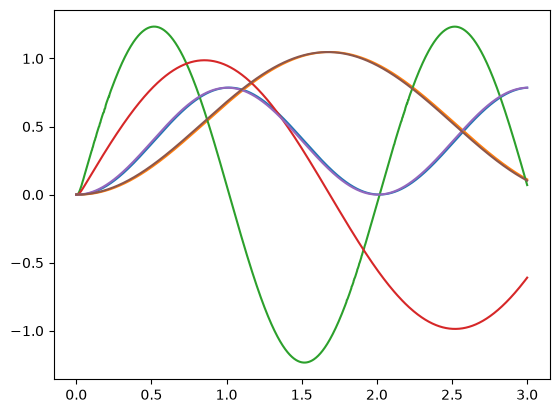

In [ ]:
plt.plot(T_t,X_t)